# Blood Cell AI - ResNet18 Training

ResNet18（Functional API）による血液細胞2クラス分類

※ PyTorch版 torchvision.models.resnet18 と同じアーキテクチャ
※ USE_PRETRAINED=True でPyTorch ImageNet学習済み重みをロード可能
※ 28x28入力（PyTorch版と同じ条件）
※ カスタムLayer-subclassを使わずFunctional APIで実装（DirectML互換）

## 1. インポートと設定

In [1]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'false'
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import sys
import time
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

sys.path.append(os.path.abspath('..'))
from utils.results import save_results

# === 設定 ===
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

# PyTorch ImageNet学習済み重みを使うか
USE_PRETRAINED = True
PRETRAINED_PATH = '../models/resnet18_imagenet_weights.npz'

# 転移学習アプローチ
USE_FINETUNING = False
APPROACH = 'finetuning' if USE_FINETUNING else 'feature_extraction'
WEIGHT_TAG = 'pretrained' if USE_PRETRAINED else 'scratch'

MODEL_SAVE_PATH = f'../models/resnet18_bloodcell_{APPROACH}.weights.h5'
RESULTS_SAVE_PATH = f'../models/resnet18_{APPROACH}_results.yaml'
CURVE_SAVE_PATH = f'../images/resnet18_learning_curve_{APPROACH}.png'

# GPU確認
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU: {gpus[0].name}')
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=16384)]
    )
    print('GPU memory limit: 4096 MB')
else:
    print('GPUなし（CPUモード）')

print(f'アプローチ: {APPROACH}')
print(f'学習済み重み: {"ImageNet（PyTorch変換）" if USE_PRETRAINED else "スクラッチ学習"}')

W0000 00:00:1782174964.647913   21053 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782174964.648200   21053 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782174964.648208   21053 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782174964.648213   21053 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
2026-06-23 00:36:04.679262: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow wi

GPU: /physical_device:GPU:0
GPU memory limit: 4096 MB
アプローチ: feature_extraction
学習済み重み: ImageNet（PyTorch変換）


## 2. データロード

In [2]:
from medmnist import BloodMNIST

MATURE_LABELS = {0, 1, 4, 5, 6, 7}
IMMATURE_LABELS = {2, 3}
def get_binary_label(label):
    return 1 if label in IMMATURE_LABELS else 0

train_dataset = BloodMNIST(split='train', download=True, root='../data')
val_dataset = BloodMNIST(split='val', download=True, root='../data')
test_dataset = BloodMNIST(split='test', download=True, root='../data')

x_train = train_dataset.imgs.astype('float32') / 255.0
y_train = np.array([get_binary_label(int(l)) for l in train_dataset.labels.squeeze()])
x_val = val_dataset.imgs.astype('float32') / 255.0
y_val = np.array([get_binary_label(int(l)) for l in val_dataset.labels.squeeze()])
x_test = test_dataset.imgs.astype('float32') / 255.0
y_test = np.array([get_binary_label(int(l)) for l in test_dataset.labels.squeeze()])

AUTOTUNE = tf.data.AUTOTUNE
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
])

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(len(x_train)).batch(BATCH_SIZE)
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(f'Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}')

I0000 00:00:1782174996.751682   21053 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 0, name: AMD Radeon RX 7900 XT, pci bus id: 0000:2d:00.0


Train: 11959, Val: 1712, Test: 3421


## 3. ResNet18モデル構築（Functional API）

PyTorch torchvision.models.resnet18 と同じBasicBlock構成 `[2,2,2,2]`。
ROCm/GPU互換のためLayer-subclassを使わずFunctional APIで実装。

In [3]:
def basic_block(x, filters, stride=1, downsample_filters=None, name_prefix='', training=None):
    """ResNet BasicBlock（Functional API）
    PyTorch torchvisionと同じ構成
    """
    identity = x
    # Conv→BN→ReLU→Conv→BN
    out = layers.Conv2D(filters, 3, strides=stride, padding='same',
                        use_bias=False, name=f'{name_prefix}_conv1')(x)
    out = layers.BatchNormalization(name=f'{name_prefix}_bn1')(out, training=training)
    out = layers.ReLU(name=f'{name_prefix}_relu1')(out)
    out = layers.Conv2D(filters, 3, strides=1, padding='same',
                        use_bias=False, name=f'{name_prefix}_conv2')(out)
    out = layers.BatchNormalization(name=f'{name_prefix}_bn2')(out, training=training)
    # Downsample（チャンネル数・空間サイズ変更時）
    if downsample_filters is not None:
        identity = layers.Conv2D(downsample_filters, 1, strides=stride,
                                  padding='same', use_bias=False,
                                  name=f'{name_prefix}_downsample_0')(x)
        identity = layers.BatchNormalization(name=f'{name_prefix}_downsample_1')(identity, training=training)
    # Residual + ReLU
    out = layers.Add(name=f'{name_prefix}_add')([out, identity])
    out = layers.ReLU(name=f'{name_prefix}_relu2')(out)
    return out

def build_resnet18(input_shape=(28, 28, 3), num_classes=2):
    """ResNet18 [2,2,2,2] BasicBlock（Functional API）"""
    inputs = layers.Input(shape=input_shape)
    # 初期層（28x28入力用: stride=1, maxpoolなし）
    x = layers.Conv2D(64, 7, strides=1, padding='same', use_bias=False, name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.ReLU(name='relu1')(x)
    # layer1: 2 blocks, 64 channels
    x = basic_block(x, 64, stride=1, name_prefix='layer1_block0', training=None)
    x = basic_block(x, 64, stride=1, name_prefix='layer1_block1', training=None)
    # layer2: 2 blocks, 128 channels
    x = basic_block(x, 128, stride=2, downsample_filters=128, name_prefix='layer2_block0', training=None)
    x = basic_block(x, 128, stride=1, name_prefix='layer2_block1', training=None)
    # layer3: 2 blocks, 256 channels
    x = basic_block(x, 256, stride=2, downsample_filters=256, name_prefix='layer3_block0', training=None)
    x = basic_block(x, 256, stride=1, name_prefix='layer3_block1', training=None)
    # layer4: 2 blocks, 512 channels
    x = basic_block(x, 512, stride=2, downsample_filters=512, name_prefix='layer4_block0', training=None)
    x = basic_block(x, 512, stride=1, name_prefix='layer4_block1', training=None)
    # 出力
    x = layers.GlobalAveragePooling2D(name='avgpool')(x)
    x = layers.Dense(num_classes, activation='softmax', name='fc')(x)
    return keras.Model(inputs, x, name='ResNet18')

model = build_resnet18(input_shape=(28, 28, 3), num_classes=2)
model.summary()
print(f'\nパラメータ数: {model.count_params():,}')
print(f'学習済み重み: {"ImageNet（PyTorch変換）" if USE_PRETRAINED else "スクラッチ学習"}')

Model: "ResNet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 28, 28,    │      9,408 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 28, 28,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (ReLU)        │ (None, 28, 28,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block0_conv1 │ (None, 28, 28,    │     36,864 │ relu1[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block0_bn1   │ (None, 28, 28,    │        256 │ layer1_block0_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block0_relu1 │ (None, 28, 28,    │          0 │ layer1_block0_bn… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block0_conv2 │ (None, 28, 28,    │     36,864 │ layer1_block0_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block0_bn2   │ (None, 28, 28,    │        256 │ layer1_block0_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block0_add   │ (None, 28, 28,    │          0 │ layer1_block0_bn… │
│ (Add)               │ 64)               │            │ relu1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block0_relu2 │ (None, 28, 28,    │          0 │ layer1_block0_ad… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_conv1 │ (None, 28, 28,    │     36,864 │ layer1_block0_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_bn1   │ (None, 28, 28,    │        256 │ layer1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_relu1 │ (None, 28, 28,    │          0 │ layer1_block1_bn… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_conv2 │ (None, 28, 28,    │     36,864 │ layer1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_bn2   │ (None, 28, 28,    │        256 │ layer1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_add   │ (None, 28, 28,    │          0 │ layer1_block1_bn

 Total params: 11,187,138 (42.68 MB)

 Trainable params: 11,177,538 (42.64 MB)

 Non-trainable params: 9,600 (37.50 KB)


パラメータ数: 11,187,138
学習済み重み: ImageNet（PyTorch変換）


## 4. PyTorch重みのロード（オプション）

In [4]:
def load_pytorch_pretrained(model, npz_path):
    """変換済みのPyTorch ImageNet重みをTFモデルにロード"""
    weights = np.load(npz_path)
    loaded_count = 0
    skipped = []
    for layer in model.layers:
        layer_weights = {}
        for key in weights.files:
            key_prefix = key.rsplit('/', 1)[0]
            key_suffix = key.rsplit('/', 1)[1]
            # npzのlayerX_Y → TFのlayerX_blockY に変換
            import re
            key_prefix = re.sub(r'layer(\d+)_(\d+)', r'layer\1_block\2', key_prefix)
            if key_prefix == layer.name:
                layer_weights[key_suffix] = weights[key]
        if not layer_weights:
            continue
        try:
            current = layer.get_weights()
            if isinstance(layer, layers.Conv2D):
                if 'kernel' in layer_weights:
                    new_w = [layer_weights['kernel']]
                    if len(current) > 1 and layer.use_bias:
                        new_w.extend(current[1:])
                    layer.set_weights(new_w)
                    loaded_count += 1
            elif isinstance(layer, layers.BatchNormalization):
                bn_keys = ['gamma', 'beta', 'moving_mean', 'moving_variance']
                bn_w = [layer_weights.get(k, current[i]) for i, k in enumerate(bn_keys)]
                layer.set_weights(bn_w)
                loaded_count += 1
            elif isinstance(layer, layers.Dense):
                new_w = []
                if 'kernel' in layer_weights:
                    new_w.append(layer_weights['kernel'])
                if 'bias' in layer_weights:
                    new_w.append(layer_weights['bias'])
                if new_w:
                    layer.set_weights(new_w)
                    loaded_count += 1
        except Exception as e:
            skipped.append(f'{layer.name}: {e}')
    if skipped:
        print(f'スキップ: {skipped}')
    print(f'Pretrained重みロード完了: {loaded_count}層')
    return loaded_count

# 学習済み重みのロード
if USE_PRETRAINED and os.path.exists(PRETRAINED_PATH):
    print(f'ImageNet学習済み重みをロード: {PRETRAINED_PATH}')
    load_pytorch_pretrained(model, PRETRAINED_PATH)
elif USE_PRETRAINED:
    print(f'⚠️ 重みファイルが見つかりません: {PRETRAINED_PATH}')
    print('スクラッチ学習で続行します')

# Feature Extraction: 最終層以外を固定
if USE_PRETRAINED and not USE_FINETUNING:
    for layer in model.layers:
        if layer.name != 'fc':
            layer.trainable = False
    print('Feature Extraction: 最終層以外を固定')
    model.get_layer('fc').trainable = True
else:
    print('Fine-tuning: 全パラメータを学習')

ImageNet学習済み重みをロード: ../models/resnet18_imagenet_weights.npz
Pretrained重みロード完了: 40層
Feature Extraction: 最終層以外を固定


## 5. コンパイルとコールバック

In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# 重みのみ保存（DirectML+カスタムモデルの安定性向上のため）
callbacks = [
    keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy',
                                     save_best_only=True, save_weights_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=7,
                                    restore_best_weights=True, verbose=1),
]
print('モデルコンパイル完了')

モデルコンパイル完了


## 6. 学習実行

In [6]:
print(f'\n=== Training ResNet18 ({APPROACH}, {WEIGHT_TAG}) ===')
start_time = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
training_time = time.time() - start_time
print(f'\nTraining Time: {training_time:.1f}秒 ({training_time/60:.1f}分)')


=== Training ResNet18 (feature_extraction, pretrained) ===
Epoch 1/10


I0000 00:00:1782175003.538467   21147 service.cc:152] XLA service 0x7b096c0014c0 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782175003.538566   21147 service.cc:160]   StreamExecutor device (0): AMD Radeon RX 7900 XT, AMDGPU ISA version: gfx1100
2026-06-23 00:36:43.617254: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782175007.737481   21147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7127 - loss: 0.5986
Epoch 1: val_accuracy improved from None to 0.78738, saving model to ../models/resnet18_bloodcell_feature_extraction.weights.h5
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.7592 - loss: 0.5087 - val_accuracy: 0.7874 - val_loss: 0.4473
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8074 - loss: 0.4055
Epoch 2: val_accuracy improved from 0.78738 to 0.81308, saving model to ../models/resnet18_bloodcell_feature_extraction.weights.h5
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8150 - loss: 0.3932 - val_accuracy: 0.8131 - val_loss: 0.4011
Epoch 3/10
 93/187 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8239 - loss: 0.3755
Epoch 3: val_accuracy improved from 0.81308 to 0.81893, saving model to ../models/resnet18_bloodcell_feature_extraction.weights.h5
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8283 - loss: 0.3670 - val_accuracy: 0.8189 - val_loss: 0.3924
Epoch 

## 7. 学習曲線

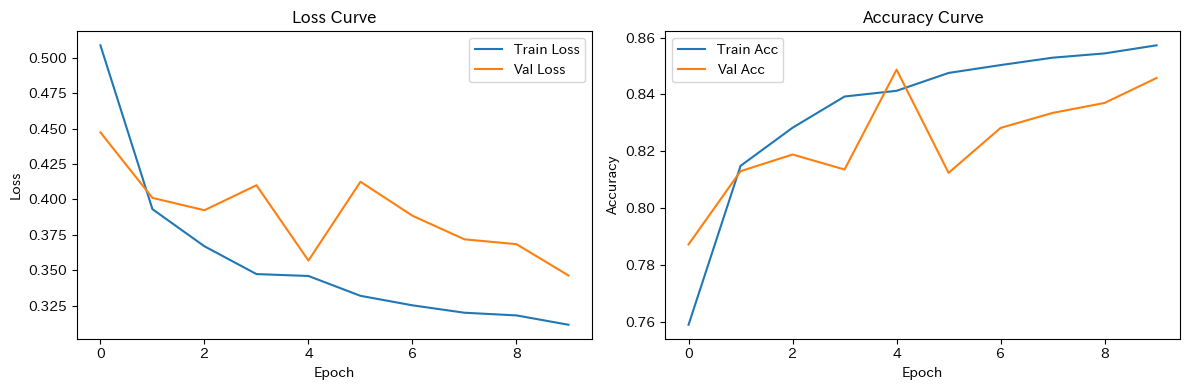

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss Curve'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Accuracy Curve'); axes[1].legend()
plt.tight_layout()
os.makedirs('../images', exist_ok=True)
plt.savefig(CURVE_SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()

## 8. テスト評価

In [8]:
print('\n=== Test Evaluation ===')
# 重みのみ保存したのでモデルを再構築してロード
best_model = build_resnet18(input_shape=(28, 28, 3), num_classes=2)
best_model.load_weights(MODEL_SAVE_PATH)
best_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
y_pred_proba = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_proba, axis=1)
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='binary')
cm = confusion_matrix(y_test, y_pred)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')
print(f'Confusion Matrix:\n{cm}')

results = {
    'model': 'ResNet18', 'approach': APPROACH,
    'test_accuracy': float(test_acc), 'test_f1': float(test_f1),
    'confusion_matrix': cm.tolist(),
    'training_time_minutes': round(training_time / 60, 1),
    'epochs': EPOCHS, 'batch_size': BATCH_SIZE, 'learning_rate': LR,
    'pretrained': USE_PRETRAINED,
    'framework': 'TensorFlow 2.10 + DirectML'
}
os.makedirs(os.path.dirname(RESULTS_SAVE_PATH), exist_ok=True)
save_results(results, RESULTS_SAVE_PATH)


=== Test Evaluation ===
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step
Test Accuracy: 0.8384
Test F1 Score: 0.6520
Confusion Matrix:
[[2350  181]
 [ 372  518]]
結果を保存しました: ../models/resnet18_feature_extraction_results.yaml


## ✅ ResNet18学習完了

次: `03_ViT学習.ipynb` → ViT-B/16で学習